# 04 — Classical ML Baseline
## GTZAN Music Genre Classification

This notebook evaluates handcrafted audio features with four classical machine-learning models:

1. SVM — RBF kernel
2. KNN
3. Random Forest
4. XGBoost

### Experimental rules

- The existing `split` column in `handcrafted_features.csv` is the **only** train/validation/test split.
- No new random split is created.
- Model selection uses **validation Macro F1**.
- The test set remains untouched until the final evaluation of the selected model.
- All models use the same handcrafted feature matrix.
- Random seed: `42`.

In [1]:
# =========================
# 1. Install dependencies
# =========================
import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
    "xgboost": "xgboost",
}

missing = [pkg for module, pkg in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

print("Dependencies ready.")

Dependencies ready.


In [2]:
# =========================
# 2. Imports and settings
# =========================
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Locate the handcrafted feature CSV

The feature extractor produced a CSV with:

- 1000 songs
- 3 metadata columns
- 137 numeric handcrafted features
- 140 total columns

The notebook first checks common Colab/local locations. If the file is not found, upload it to the notebook runtime.

In [3]:
# =========================
# 3. Locate input CSV
# =========================
candidate_paths = [
    Path("/content/handcrafted_output/handcrafted_features.csv"),
    Path("/content/handcrafted_features.csv"),
    Path("handcrafted_output/handcrafted_features.csv"),
    Path("data/processed/handcrafted_features.csv"),
    Path("data/handcrafted_features.csv"),
    Path("handcrafted_features.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    try:
        from google.colab import files
        print("handcrafted_features.csv was not found.")
        print("Please upload the generated CSV now.")
        uploaded = files.upload()
        if "handcrafted_features.csv" in uploaded:
            csv_path = Path("/content/handcrafted_features.csv")
        elif uploaded:
            first_name = next(iter(uploaded))
            csv_path = Path("/content") / first_name
    except ImportError:
        pass

if csv_path is None or not csv_path.exists():
    raise FileNotFoundError(
        "Could not find handcrafted_features.csv. "
        "Place it in the working directory or upload it in Colab."
    )

print("Using:")
print(csv_path.resolve())

handcrafted_features.csv was not found.
Please upload the generated CSV now.


Saving handcrafted_features.csv to handcrafted_features.csv
Using:
/content/handcrafted_features.csv


In [4]:
# =========================
# 4. Load and validate data
# =========================
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
display(df.head())

required_metadata = {"relative_path", "genre", "split"}
missing_metadata = required_metadata - set(df.columns)

if missing_metadata:
    raise ValueError(f"Missing required metadata columns: {missing_metadata}")

if df[["relative_path", "genre", "split"]].isnull().any().any():
    raise ValueError("Missing values found in metadata columns.")

allowed_splits = {"train", "validation", "test"}
actual_splits = set(df["split"].unique())

if actual_splits != allowed_splits:
    raise ValueError(
        f"Unexpected split labels. Expected {allowed_splits}, got {actual_splits}"
    )

numeric_features = [
    c for c in df.columns
    if c not in ["relative_path", "genre", "split"]
]

if len(numeric_features) != 137:
    raise ValueError(
        f"Expected 137 handcrafted features, found {len(numeric_features)}."
    )

if df[numeric_features].isnull().any().any():
    bad = int(df[numeric_features].isnull().sum().sum())
    raise ValueError(f"Found {bad} missing numeric feature values.")

print("\nValidation successful.")
print("Songs:", len(df))
print("Numeric features:", len(numeric_features))
print("\nSplit counts:")
print(df["split"].value_counts().sort_index())
print("\nGenre counts:")
print(df["genre"].value_counts().sort_index())

Shape: (1000, 140)


,relative_path,genre,split,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,...,spectral_entropy_std,spectral_skewness_mean,spectral_skewness_std,spectral_kurtosis_mean,spectral_kurtosis_std,rms_mean,rms_std,zcr_mean,zcr_std,tempo
0,genres/blues/blues.00001.au,blues,test,-207.52383,123.985140,8.947019,35.867150,2.909595,21.519474,-8.556513,...,0.925271,1.982395,0.775544,6.985289,4.370101,0.095908,0.048711,0.056040,0.038046,107.666016
1,genres/blues/blues.00021.au,blues,test,-264.67126,138.854340,11.167330,48.523926,14.904312,20.586437,3.206176,...,1.061260,2.927463,1.211712,13.932757,8.048373,0.101084,0.056842,0.047907,0.048284,99.384020
2,genres/blues/blues.00029.au,blues,test,-233.72897,101.190280,17.647955,23.734173,2.082546,25.936398,-16.956385,...,0.915775,1.931668,0.889917,6.505280,4.094134,0.124684,0.069377,0.052895,0.056986,129.199220
3,genres/blues/blues.00032.au,blues,test,-288.73270,105.901150,18.776207,23.682646,5.682041,25.548940,-13.463247,...,0.921638,2.581413,1.226806,10.821723,8.011728,0.101225,0.062758,0.039388,0.056197,123.046875
4,genres/blues/blues.00037.au,blues,test,-328.56018,102.709816,19.872597,26.714405,7.152066,22.708387,-6.957089,...,0.950945,2.949817,1.551546,14.397697,15.481927,0.069158,0.047235,0.048164,0.035665,123.046875



Validation successful.
Songs: 1000
Numeric features: 137

Split counts:
split
test          150
train         700
validation    150
Name: count, dtype: int64

Genre counts:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


## 5. Prepare train, validation, and test sets

No split is generated here.

The rows are selected directly from the `split` column created by the project's leakage-aware manifest pipeline.

In [5]:
# =========================
# 5. Build X/y from existing split
# =========================
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "validation"].copy()
test_df  = df[df["split"] == "test"].copy()

X_train = train_df[numeric_features].astype(np.float32)
y_train = train_df["genre"].astype(str)

X_val = val_df[numeric_features].astype(np.float32)
y_val = val_df["genre"].astype(str)

X_test = test_df[numeric_features].astype(np.float32)
y_test = test_df["genre"].astype(str)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

assert len(X_train) == 700
assert len(X_val) == 150
assert len(X_test) == 150

assert set(train_df["relative_path"]).isdisjoint(val_df["relative_path"])
assert set(train_df["relative_path"]).isdisjoint(test_df["relative_path"])
assert set(val_df["relative_path"]).isdisjoint(test_df["relative_path"])

print("\nLeakage checks passed.")

Train: (700, 137)
Validation: (150, 137)
Test: (150, 137)

Leakage checks passed.


## 6. Define evaluation function

The primary selection metric is **Macro F1** because every genre should contribute equally to the model-selection decision.

We also report:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1

In [6]:
# =========================
# 6. Evaluation helpers
# =========================
from sklearn.preprocessing import LabelEncoder

# XGBoost requires integer class labels.
# The other sklearn models can continue using the original genre strings.
label_encoder = LabelEncoder()
label_encoder.fit(sorted(df["genre"].astype(str).unique()))

y_train_xgb = label_encoder.transform(y_train)
y_val_xgb = label_encoder.transform(y_val)
y_test_xgb = label_encoder.transform(y_test)

print("XGBoost label mapping:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {idx} -> {label}")


def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }


def evaluate_on_validation(name, model):
    print(f"\n{'=' * 70}")
    print(name)
    print(f"{'=' * 70}")

    # XGBoost needs integer-encoded labels.
    if name == "XGBoost":
        model.fit(X_train, y_train_xgb)
        pred_encoded = model.predict(X_val).astype(int).ravel()
        pred = label_encoder.inverse_transform(pred_encoded)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_val)

    metrics = calculate_metrics(y_val, pred)
    metrics["model"] = name

    print(f"Accuracy        : {metrics['accuracy']:.4f}")
    print(f"Macro Precision : {metrics['macro_precision']:.4f}")
    print(f"Macro Recall    : {metrics['macro_recall']:.4f}")
    print(f"Macro F1        : {metrics['macro_f1']:.4f}")
    print(f"Weighted F1     : {metrics['weighted_f1']:.4f}")

    return model, pred, metrics

XGBoost label mapping:
  0 -> blues
  1 -> classical
  2 -> country
  3 -> disco
  4 -> hiphop
  5 -> jazz
  6 -> metal
  7 -> pop
  8 -> reggae
  9 -> rock


# 7. Classical ML baseline models

These are intentionally fixed baseline configurations.

### SVM
`StandardScaler → RBF SVM`

### KNN
`StandardScaler → KNN`

### Random Forest
Tree ensemble; scaling is not required.

### XGBoost
Gradient-boosted decision trees; scaling is not required.

In [7]:
# =========================
# 7. Define baseline models
# =========================

models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            random_state=RANDOM_STATE
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=7,
            weights="distance"
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    ),
}

print("Models:")
for name in models:
    print("-", name)

Models:
- SVM
- KNN
- Random Forest
- XGBoost


In [8]:
# =========================
# 8. Run validation baselines
# =========================
validation_results = []
fitted_models = {}
validation_predictions = {}

for name, model in models.items():
    fitted, pred, metrics = evaluate_on_validation(name, model)
    fitted_models[name] = fitted
    validation_predictions[name] = pred
    validation_results.append(metrics)

validation_table = (
    pd.DataFrame(validation_results)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)

print("\nValidation results:")
display(validation_table.style.format("{:.4f}"))


SVM
Accuracy        : 0.7800
Macro Precision : 0.7863
Macro Recall    : 0.7800
Macro F1        : 0.7791
Weighted F1     : 0.7791

KNN
Accuracy        : 0.6600
Macro Precision : 0.6787
Macro Recall    : 0.6600
Macro F1        : 0.6539
Weighted F1     : 0.6539

Random Forest
Accuracy        : 0.7867
Macro Precision : 0.7894
Macro Recall    : 0.7867
Macro F1        : 0.7855
Weighted F1     : 0.7855

XGBoost
Accuracy        : 0.7667
Macro Precision : 0.7694
Macro Recall    : 0.7667
Macro F1        : 0.7625
Weighted F1     : 0.7625

Validation results:


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
model,,,,,
Random Forest,0.7867,0.7894,0.7867,0.7855,0.7855
SVM,0.7800,0.7863,0.7800,0.7791,0.7791
XGBoost,0.7667,0.7694,0.7667,0.7625,0.7625
KNN,0.6600,0.6787,0.6600,0.6539,0.6539


## 9. Select the best baseline

The winner is selected using **validation Macro F1 only**.

The test set has not been used for this decision.

In [9]:
# =========================
# 9. Select best baseline
# =========================
best_baseline_name = validation_table["macro_f1"].idxmax()
best_validation_f1 = validation_table.loc[best_baseline_name, "macro_f1"]

print("Best baseline model:", best_baseline_name)
print(f"Validation Macro F1: {best_validation_f1:.4f}")

Best baseline model: Random Forest
Validation Macro F1: 0.7855


In [10]:
# =========================
# 10. Validation classification reports
# =========================
for name in validation_table.index:
    print("\n" + "=" * 80)
    print(f"{name} — validation classification report")
    print("=" * 80)

    print(
        classification_report(
            y_val,
            validation_predictions[name],
            digits=4,
            zero_division=0
        )
    )


Random Forest — validation classification report
              precision    recall  f1-score   support

       blues     0.7500    0.8000    0.7742        15
   classical     0.9375    1.0000    0.9677        15
     country     0.7857    0.7333    0.7586        15
       disco     0.5556    0.6667    0.6061        15
      hiphop     0.7647    0.8667    0.8125        15
        jazz     1.0000    0.9333    0.9655        15
       metal     0.9286    0.8667    0.8966        15
         pop     0.8125    0.8667    0.8387        15
      reggae     0.6923    0.6000    0.6429        15
        rock     0.6667    0.5333    0.5926        15

    accuracy                         0.7867       150
   macro avg     0.7894    0.7867    0.7855       150
weighted avg     0.7894    0.7867    0.7855       150


SVM — validation classification report
              precision    recall  f1-score   support

       blues     0.7647    0.8667    0.8125        15
   classical     1.0000    1.0000    1.000

# 11. Validation confusion matrices

These matrices are for model comparison during development.

The final test confusion matrix is generated later, only for the selected model.

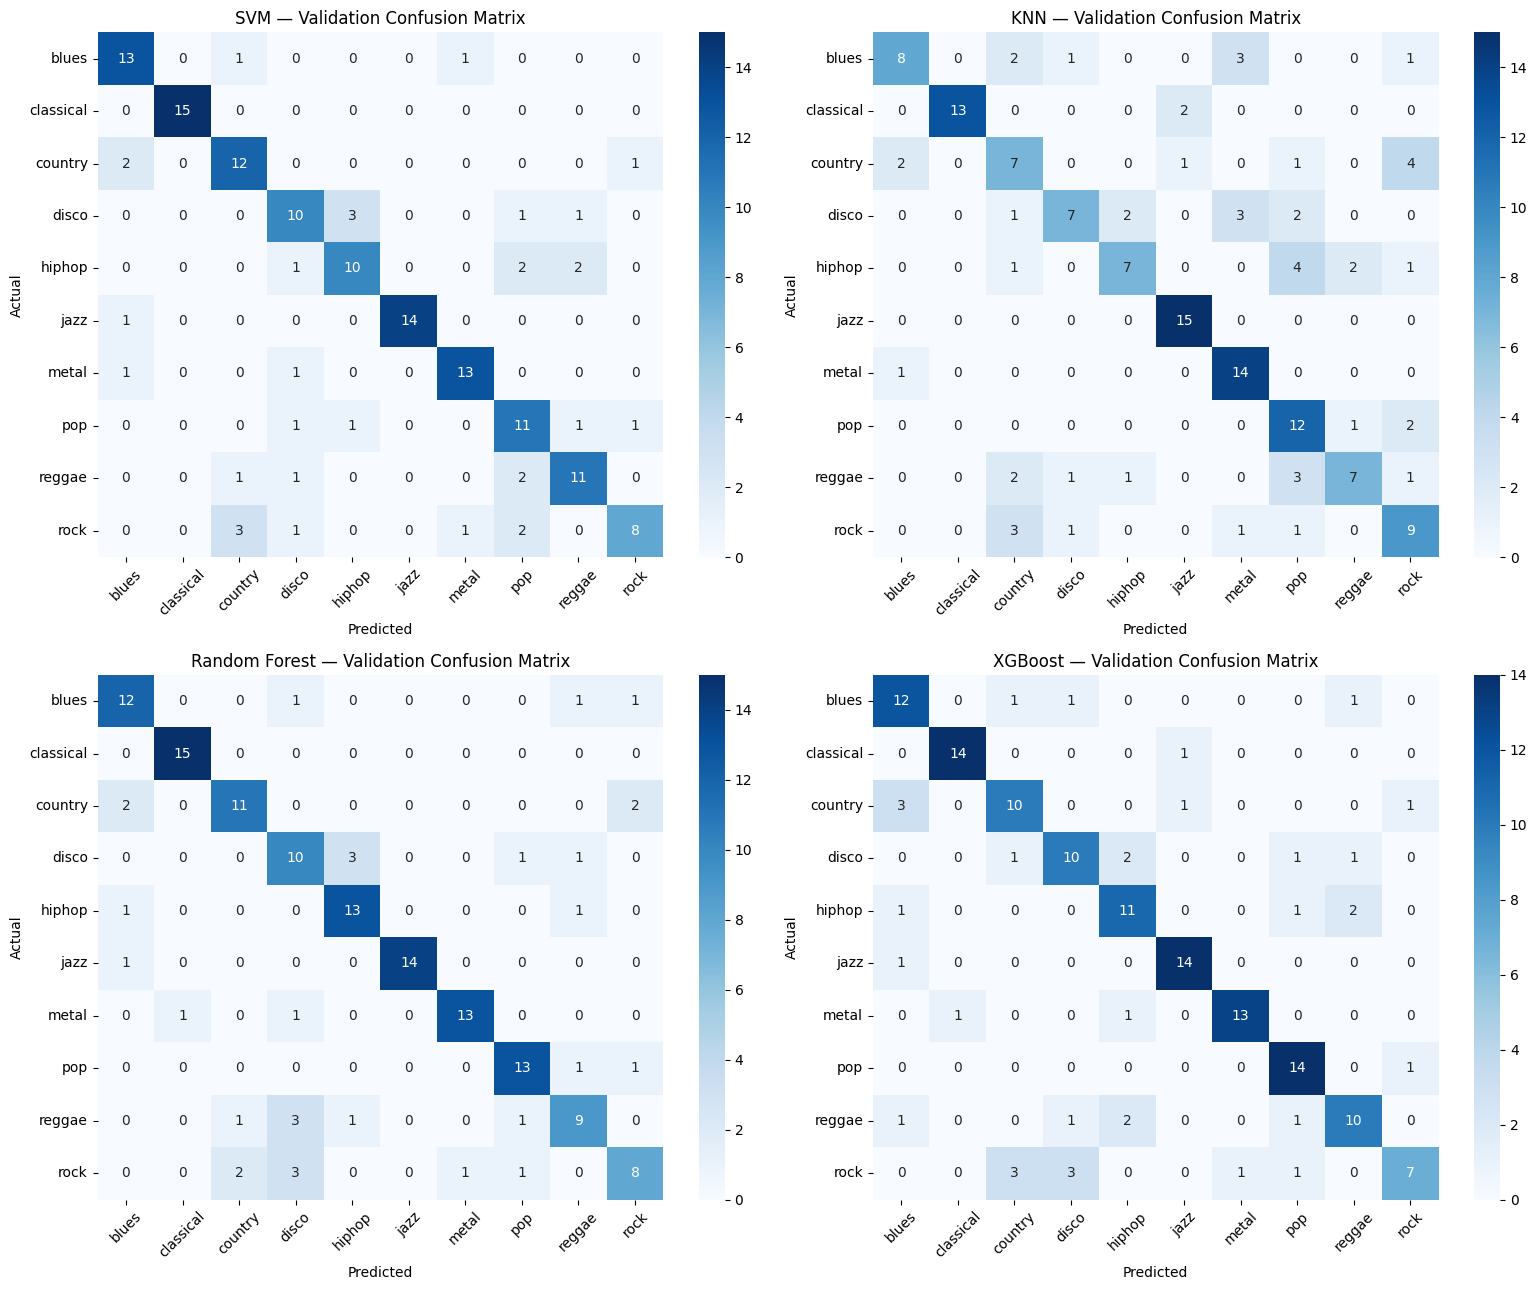

In [11]:
# =========================
# 11. Validation confusion matrices
# =========================
genres = sorted(df["genre"].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, validation_predictions.items()):
    cm = confusion_matrix(y_val, pred, labels=genres)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=genres,
        yticklabels=genres,
        ax=ax
    )

    ax.set_title(f"{name} — Validation Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 12. Compare baseline models

This table is the main baseline result for the classical-ML branch.

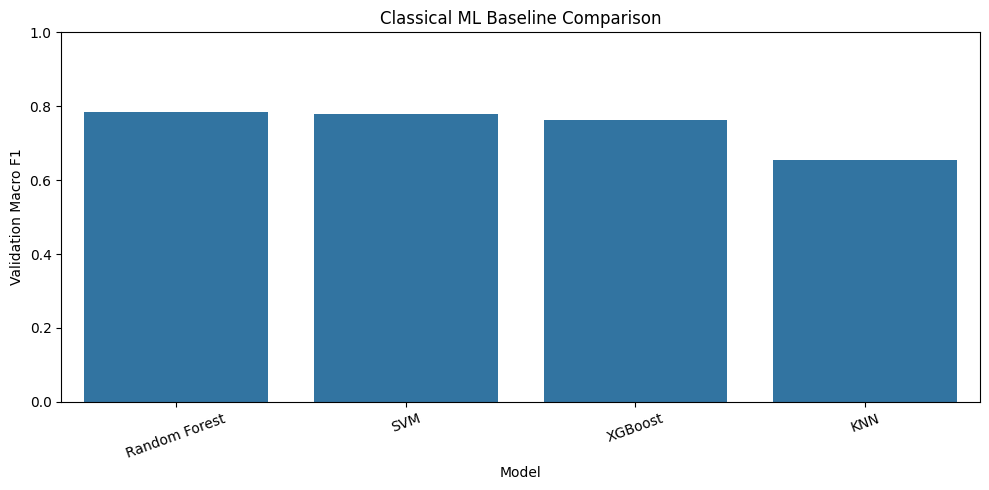

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
model,,,,,
Random Forest,0.7867,0.7894,0.7867,0.7855,0.7855
SVM,0.7800,0.7863,0.7800,0.7791,0.7791
XGBoost,0.7667,0.7694,0.7667,0.7625,0.7625
KNN,0.6600,0.6787,0.6600,0.6539,0.6539


In [12]:
# =========================
# 12. Baseline comparison plot
# =========================
plot_table = validation_table.reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=plot_table,
    x="model",
    y="macro_f1"
)

plt.ylim(0, 1)
plt.ylabel("Validation Macro F1")
plt.xlabel("Model")
plt.title("Classical ML Baseline Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(
    validation_table[
        ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]
    ].style.format("{:.4f}")
)

# 13. Final evaluation protocol

Now the best baseline model is retrained using:

**train + validation**

The held-out test set is evaluated exactly once for the final performance estimate.

This avoids selecting the model based on test performance.

In [13]:
# =========================
# 13. Refit best model on train + validation
# =========================
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_model = models[best_baseline_name]

print("Best model:", best_baseline_name)
print("Train + validation samples:", len(X_trainval))
print("Held-out test samples:", len(X_test))

if best_baseline_name == "XGBoost":
    y_trainval_xgb = label_encoder.transform(y_trainval)
    best_model.fit(X_trainval, y_trainval_xgb)

    test_pred_encoded = best_model.predict(X_test).astype(int).ravel()
    test_pred = label_encoder.inverse_transform(test_pred_encoded)
else:
    best_model.fit(X_trainval, y_trainval)
    test_pred = best_model.predict(X_test)

test_metrics = calculate_metrics(y_test, test_pred)

print("\nFINAL TEST RESULTS")
print("=" * 60)
for key, value in test_metrics.items():
    print(f"{key:16s}: {value:.4f}")

Best model: Random Forest
Train + validation samples: 850
Held-out test samples: 150

FINAL TEST RESULTS
accuracy        : 0.7467
macro_precision : 0.7476
macro_recall    : 0.7467
macro_f1        : 0.7377
weighted_f1     : 0.7377


In [14]:
# =========================
# 14. Final test classification report
# =========================
print("=" * 80)
print(f"{best_baseline_name} — FINAL TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        test_pred,
        labels=genres,
        digits=4,
        zero_division=0
    )
)

Random Forest — FINAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

       blues     0.6842    0.8667    0.7647        15
   classical     0.8750    0.9333    0.9032        15
     country     0.6471    0.7333    0.6875        15
       disco     0.8182    0.6000    0.6923        15
      hiphop     0.7500    0.8000    0.7742        15
        jazz     0.7222    0.8667    0.7879        15
       metal     0.8462    0.7333    0.7857        15
         pop     0.7222    0.8667    0.7879        15
      reggae     0.7857    0.7333    0.7586        15
        rock     0.6250    0.3333    0.4348        15

    accuracy                         0.7467       150
   macro avg     0.7476    0.7467    0.7377       150
weighted avg     0.7476    0.7467    0.7377       150



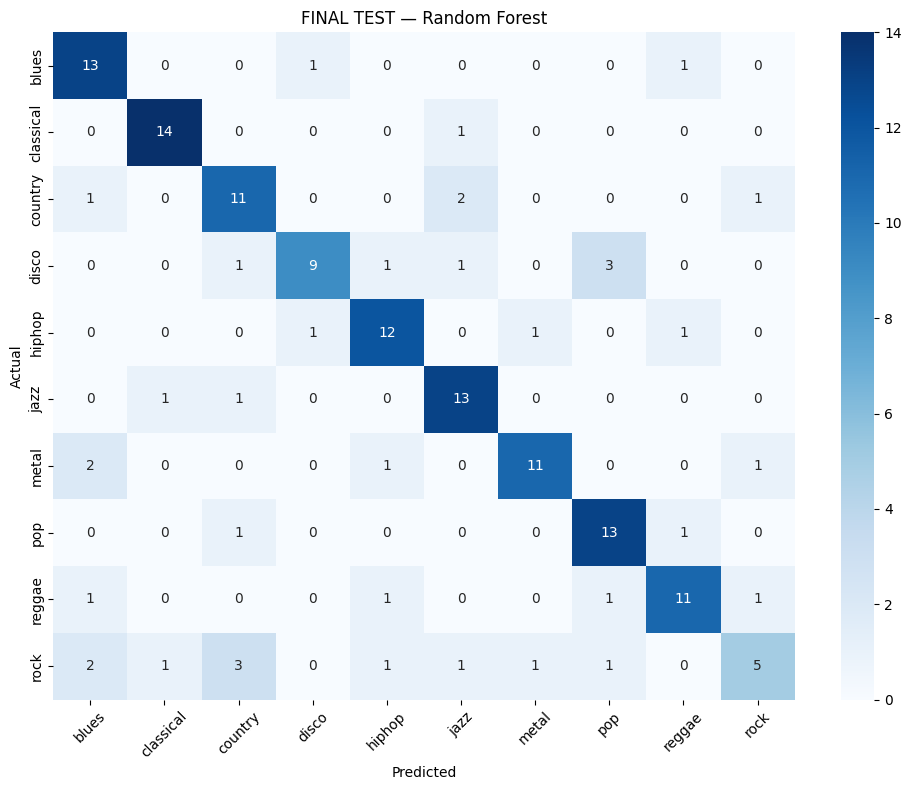

In [15]:
# =========================
# 15. Final test confusion matrix
# =========================
test_cm = confusion_matrix(y_test, test_pred, labels=genres)

plt.figure(figsize=(10, 8))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=genres,
    yticklabels=genres
)

plt.title(f"FINAL TEST — {best_baseline_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 16. Most confused genre pairs

This helps with the project's error-analysis section.

In [16]:
# =========================
# 16. Find strongest confusion pairs
# =========================
confusions = []

for i, actual in enumerate(genres):
    for j, predicted in enumerate(genres):
        if i != j and test_cm[i, j] > 0:
            confusions.append({
                "actual": actual,
                "predicted": predicted,
                "count": int(test_cm[i, j])
            })

confusion_pairs = (
    pd.DataFrame(confusions)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("Most frequent test-set confusion pairs:")
display(confusion_pairs.head(15))

Most frequent test-set confusion pairs:


,actual,predicted,count
0,disco,pop,3
1,rock,country,3
2,country,jazz,2
3,metal,blues,2
4,rock,blues,2
5,classical,jazz,1
6,blues,reggae,1
7,disco,country,1
8,disco,hiphop,1
9,disco,jazz,1


# 17. Save results

The notebook saves only experiment outputs and the trained classical model.

The raw GTZAN audio is **not** saved by this notebook.

In [17]:
# =========================
# 17. Save results
# =========================
results_dir = Path("results")
tables_dir = results_dir / "tables"
figures_dir = results_dir / "figures"
models_dir = Path("models")

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# Validation results
validation_table.to_csv(tables_dir / "classical_ml_validation_results.csv")

# Final test metrics
final_test_table = pd.DataFrame([test_metrics])
final_test_table.insert(0, "model", best_baseline_name)
final_test_table.to_csv(tables_dir / "classical_ml_final_test_results.csv", index=False)

# Final classification report
report_dict = classification_report(
    y_test,
    test_pred,
    labels=genres,
    output_dict=True,
    zero_division=0
)
pd.DataFrame(report_dict).T.to_csv(
    tables_dir / "classical_ml_final_test_classification_report.csv"
)

# Confusion matrix
pd.DataFrame(
    test_cm,
    index=genres,
    columns=genres
).to_csv(
    tables_dir / "classical_ml_final_test_confusion_matrix.csv"
)

# Most confused pairs
confusion_pairs.to_csv(
    tables_dir / "classical_ml_final_confusion_pairs.csv",
    index=False
)

# Model
model_path = models_dir / "best_classical_ml_model.joblib"
joblib.dump(best_model, model_path)

# Experiment metadata
metadata = {
    "project": "Music Genre Classification",
    "dataset": "GTZAN",
    "n_songs": int(len(df)),
    "n_features": int(len(numeric_features)),
    "feature_count": 137,
    "split_source": "existing split column in handcrafted_features.csv",
    "train_samples": int(len(X_train)),
    "validation_samples": int(len(X_val)),
    "test_samples": int(len(X_test)),
    "selection_metric": "validation_macro_f1",
    "best_baseline_model": best_baseline_name,
    "validation_macro_f1": float(best_validation_f1),
    "final_test_metrics": {
        k: float(v) for k, v in test_metrics.items()
    },
    "random_state": RANDOM_STATE,
}

with open(results_dir / "classical_ml_experiment_config.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("-", tables_dir / "classical_ml_validation_results.csv")
print("-", tables_dir / "classical_ml_final_test_results.csv")
print("-", tables_dir / "classical_ml_final_test_classification_report.csv")
print("-", tables_dir / "classical_ml_final_test_confusion_matrix.csv")
print("-", tables_dir / "classical_ml_final_confusion_pairs.csv")
print("-", model_path)
print("-", results_dir / "classical_ml_experiment_config.json")

Saved:
- results/tables/classical_ml_validation_results.csv
- results/tables/classical_ml_final_test_results.csv
- results/tables/classical_ml_final_test_classification_report.csv
- results/tables/classical_ml_final_test_confusion_matrix.csv
- results/tables/classical_ml_final_confusion_pairs.csv
- models/best_classical_ml_model.joblib
- results/classical_ml_experiment_config.json


# 18. Final experiment summary

Use the values printed below when writing the report.

Important interpretation:

- **Validation Macro F1** decides the best classical model.
- **Final Test Macro F1** is the held-out performance estimate.
- The test result should not be used to tune hyperparameters.
- Hyperparameter tuning belongs in the next notebook/experiment.

In [18]:
# =========================
# 18. Final summary
# =========================
print("=" * 80)
print("CLASSICAL ML BASELINE — FINAL SUMMARY")
print("=" * 80)

print(f"Dataset                 : GTZAN")
print(f"Songs                   : {len(df)}")
print(f"Handcrafted features    : {len(numeric_features)}")
print(f"Train / Val / Test      : {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Selection metric        : Validation Macro F1")
print(f"Best baseline           : {best_baseline_name}")
print(f"Validation Macro F1     : {best_validation_f1:.4f}")
print(f"Final Test Accuracy     : {test_metrics['accuracy']:.4f}")
print(f"Final Test Macro F1     : {test_metrics['macro_f1']:.4f}")
print(f"Final Test Macro Prec.  : {test_metrics['macro_precision']:.4f}")
print(f"Final Test Macro Recall : {test_metrics['macro_recall']:.4f}")
print(f"Final Test Weighted F1  : {test_metrics['weighted_f1']:.4f}")
print("=" * 80)

CLASSICAL ML BASELINE — FINAL SUMMARY
Dataset                 : GTZAN
Songs                   : 1000
Handcrafted features    : 137
Train / Val / Test      : 700 / 150 / 150
Selection metric        : Validation Macro F1
Best baseline           : Random Forest
Validation Macro F1     : 0.7855
Final Test Accuracy     : 0.7467
Final Test Macro F1     : 0.7377
Final Test Macro Prec.  : 0.7476
Final Test Macro Recall : 0.7467
Final Test Weighted F1  : 0.7377
